# FC Baseline for EEG Denoising CT-DCENet

### Trains a separate fully-connected denoiser for each artifact split.

In [1]:
# Expected dataset layout (produced by build_dataset1_CT_DCENet.ipynb)

# /kaggle/input/<dataset-slug>/dataset1_h5/
#     emg_train.h5   emg_val.h5   emg_test.h5
#     eog_train.h5   eog_val.h5   eog_test.h5
#     ecg_train.h5   ...
#     emg_eog_train.h5   ...
#     emg_ecg_train.h5   ...
#     eog_ecg_train.h5   ...
#     emg_eog_ecg_train.h5   ...
 
# Each .h5 file contains:
#     /clean   float32  (N, 512)   normalised ground-truth EEG
#     /noisy   float32  (N, 512)   normalised contaminated EEG
 
# Outputs (saved to /kaggle/working/)
# -------------------------------------
#     checkpoints/fc_denoiser_<combo>.pt   — best model per split
#     fc_baseline_results.csv              — all test metrics across splits

In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import HfApi, login, whoami

In [3]:
login()

In [4]:
whoami()

{'type': 'user',
 'id': '66a797b589b3e71262932d0d',
 'name': 'SurAyush',
 'fullname': 'Ayush Sur',
 'email': 'ayushsur26@gmail.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1775001600,
 'isPro': False,
 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/noauth/RZJZW_w0wdVoOmQY250lR.png',
 'orgs': [{'type': 'org',
   'id': '681b0cb0dba891d54be0773d',
   'name': 'mcp-course',
   'fullname': 'Hugging Face MCP Course',
   'email': None,
   'canPay': False,
   'billingMode': 'postpaid',
   'periodEnd': None,
   'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/62d648291fa3e4e7ae3fa6e8/itgTDqMrnvgNfJZJ4YmCt.png',
   'roleInOrg': 'read'}],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'EEG',
   'role': 'write',
   'createdAt': '2026-03-14T23:20:57.066Z'}}}

In [16]:
_DATASET_SLUG = "datasets/lucky3663/eegdenoise"          
 
H5_DIR = os.path.join("/kaggle/input", _DATASET_SLUG)
 
OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
 
SPLITS = ["emg", "eog", "ecg", "emg_eog", "emg_ecg", "eog_ecg", "emg_eog_ecg"]
 
WIN_LEN      = 512
BATCH_SIZE   = 256
EPOCHS       = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 7

HF_REPO  = "SurAyush/eeg-denoising-models"
HF_TOKEN = ""

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"H5 dir : {H5_DIR}")
print(f"Output : {OUTPUT_DIR}\n")

Device : cuda
H5 dir : /kaggle/input/datasets/lucky3663/eegdenoise
Output : /kaggle/working



In [7]:
class EEGDenoiseH5Dataset(Dataset):
    """
    RAM-preloaded Dataset. Reads the entire HDF5 file into CPU tensors once,
    then serves slices with zero per-batch I/O overhead.
    """
    def __init__(self, h5_path: str):
        with h5py.File(h5_path, "r") as hf:
            self.noisy = torch.from_numpy(hf["noisy"][:].astype(np.float32))
            self.clean = torch.from_numpy(hf["clean"][:].astype(np.float32))
        if DEVICE == "cuda":
            # Pin once at load time - avoids repeated page-locking per batch
            self.noisy = self.noisy.pin_memory()
            self.clean = self.clean.pin_memory()
 
    def __len__(self):
        return len(self.noisy)
 
    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx]
 
    def close(self):
        pass 

In [8]:
def make_loaders(combo: str):
    def _ds(split):
        path = os.path.join(H5_DIR, f"{combo}_{split}.h5")
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"HDF5 file not found: {path}\n"
                f"  H5_DIR        = {H5_DIR!r}\n"
                f"  _DATASET_SLUG = {_DATASET_SLUG!r}\n"
                f"Check that these match your Kaggle dataset."
            )
        print(f"    Loading {split}... ", end="", flush=True)
        ds = EEGDenoiseH5Dataset(path)
        print(f"{len(ds):,} rows")
        return ds
 
    tr, va, te = _ds("train"), _ds("val"), _ds("test")
 
    # num_workers=4: safe now - tensors live in shared memory after fork
    # pin_memory=False: already pinned in dataset constructor
    _kw = dict(num_workers=4, pin_memory=False, persistent_workers=True)
    return (
        DataLoader(tr, BATCH_SIZE, shuffle=True,  **_kw),
        DataLoader(va, BATCH_SIZE, shuffle=False, **_kw),
        DataLoader(te, BATCH_SIZE, shuffle=False, **_kw),
        tr, va, te,
    )
 

In [9]:
class FCDenoiser(nn.Module):
    """
    Fully-connected baseline:  512 → 1024 → 2048 → 1024 → 512
    BatchNorm + ReLU + Dropout(0.3) after each hidden layer.
    No output activation — free real-valued reconstruction.
    """
    def __init__(self, win_len: int = WIN_LEN, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(win_len, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
 
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.ReLU(), nn.Dropout(dropout),
 
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
 
            nn.Linear(1024, win_len),
        )
 
    def forward(self, x):
        return self.net(x)
 

In [10]:
def spectral_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """L1 loss on FFT magnitude spectra."""
    return nn.functional.l1_loss(
        torch.abs(torch.fft.rfft(pred,   dim=-1)),
        torch.abs(torch.fft.rfft(target, dim=-1)),
    )

In [11]:
class CombinedLoss(nn.Module):
    """MSE_time + λ × SpectralL1"""
    def __init__(self, lam: float = 0.1):
        super().__init__()
        self.mse = nn.MSELoss()
        self.lam = lam
 
    def forward(self, pred, target):
        l_mse  = self.mse(pred, target)
        l_spec = spectral_loss(pred, target)
        return l_mse + self.lam * l_spec, l_mse, l_spec

In [12]:
@torch.no_grad()
def compute_metrics(pred: torch.Tensor, target: torch.Tensor) -> dict:
    """
    RRMSE_temporal  (Eq 7) : ||x̂−x||₂ / ||x||₂           per-sample → mean
    RRMSE_spectral  (Eq 8) : ||X̂−X||₂ / ||X||₂            on FFT magnitudes
    CC              (Eq 9) : Pearson correlation            per-sample → mean
    SNR                    : 10·log10(||x||² / ||x̂−x||²)  dB
    """
    pred, target = pred.float(), target.float()
    diff = pred - target
 
    mse = torch.mean(diff ** 2).item()
 
    p_fft = torch.abs(torch.fft.rfft(pred,   dim=-1))
    t_fft = torch.abs(torch.fft.rfft(target, dim=-1))
    spec_loss = torch.mean(torch.abs(p_fft - t_fft)).item()
 
    snr = torch.mean(
        10.0 * torch.log10(
            torch.sum(target ** 2, dim=-1) /
            (torch.sum(diff   ** 2, dim=-1) + 1e-10)
        )
    ).item()
 
    rrmse_temporal = torch.mean(torch.sqrt(
        torch.sum(diff ** 2,    dim=-1) /
        (torch.sum(target ** 2, dim=-1) + 1e-10)
    )).item()
 
    spec_diff = p_fft - t_fft
    rrmse_spectral = torch.mean(torch.sqrt(
        torch.sum(spec_diff ** 2, dim=-1) /
        (torch.sum(t_fft   ** 2, dim=-1) + 1e-10)
    )).item()
 
    pred_c   = pred   - pred.mean(  dim=-1, keepdim=True)
    target_c = target - target.mean(dim=-1, keepdim=True)
    cc = torch.mean(
        torch.sum(pred_c * target_c, dim=-1) /
        torch.sqrt(
            torch.sum(pred_c   ** 2, dim=-1) *
            torch.sum(target_c ** 2, dim=-1) + 1e-10
        )
    ).item()
 
    return {
        "MSE":            mse,
        "SpectralLoss":   spec_loss,
        "SNR_dB":         snr,
        "RRMSE_temporal": rrmse_temporal,
        "RRMSE_spectral": rrmse_spectral,
        "CC":             cc,
    }

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for noisy, clean in loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        loss, _, _ = criterion(model(noisy), clean)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(noisy)
    return total / len(loader.dataset)

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total, preds, targets = 0.0, [], []
    for noisy, clean in loader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        pred = model(noisy)
        loss, _, _ = criterion(pred, clean)
        total += loss.item() * len(noisy)
        preds.append(pred.cpu())
        targets.append(clean.cpu())
    m = compute_metrics(torch.cat(preds), torch.cat(targets))
    m["loss"] = total / len(loader.dataset)
    return m

In [17]:
def upload_to_hf(local_ckpt_path: str, combo: str):
    """
    Uploads a single checkpoint to:
        {HF_REPO}/FC/fc_denoiser_{combo}.pt
    """
    try:
        from huggingface_hub import HfApi
        api = HfApi()
        # Create repo if it doesn't exist yet (no-op if it already does)
        api.create_repo(repo_id=HF_REPO, repo_type="model",
                        token=HF_TOKEN, exist_ok=True)
        api.upload_file(
            path_or_fileobj=local_ckpt_path,
            path_in_repo=f"FC/fc_denoiser_{combo}.pt",
            repo_id=HF_REPO,
            repo_type="model",
            commit_message=f"Add FC denoiser checkpoint: {combo}",
        )
        print(f"  Uploaded → hf://{HF_REPO}/FC/fc_denoiser_{combo}.pt")
    except Exception as e:
        print(f"  HF upload failed for [{combo}]: {e}")

In [18]:
def run_split(combo: str) -> dict:
    print(f"\n{'='*58}\n  SPLIT : {combo}\n{'='*58}")
 
    train_loader, val_loader, test_loader, tr_ds, va_ds, te_ds = make_loaders(combo)
 
    model     = FCDenoiser().to(DEVICE)
    criterion = CombinedLoss(lam=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
 
    best_val_loss, best_state, no_improve = float("inf"), None, 0
    history = []
 
    for epoch in range(1, EPOCHS + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_m   = evaluate(model, val_loader, criterion)
        scheduler.step(val_m["loss"])
        history.append({"epoch": epoch, "train_loss": tr_loss, **val_m})
 
        print(f"  Ep {epoch:3d}/{EPOCHS}  "
              f"train={tr_loss:.5f}  val={val_m['loss']:.5f}  "
              f"CC={val_m['CC']:.4f}  SNR={val_m['SNR_dB']:.2f}dB")
 
        if val_m["loss"] < best_val_loss - 1e-6:
            best_val_loss = val_m["loss"]
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  ↳ Early stop at epoch {epoch}.")
                break
 
    # ── Test ──
    model.load_state_dict(best_state)
    test_m = evaluate(model.to(DEVICE), test_loader, criterion)
 
    print(f"\n  ── Test [{combo}] ──")
    for k, v in test_m.items():
        if k != "loss":
            print(f"    {k:20s}: {v:.6f}")
 
    # ── Save checkpoint ──
    ckpt = os.path.join(CKPT_DIR, f"fc_denoiser_{combo}.pt")
    torch.save({
        "combo":        combo,
        "model_config": {"win_len": WIN_LEN, "dropout": 0.3},
        "state_dict":   best_state,
        "test_metrics": test_m,
        "history":      history,
    }, ckpt)
    print(f"  Saved → {ckpt}")
    
    # ── Upload to HuggingFace ──
    upload_to_hf(ckpt, combo)
 
    for ds in (tr_ds, va_ds, te_ds):
        ds.close()
 
    return {"combo": combo, **{k: v for k, v in test_m.items() if k != "loss"}}

In [19]:
results = [run_split(c) for c in SPLITS]

df      = pd.DataFrame(results).set_index("combo")
out_csv = os.path.join(OUTPUT_DIR, "fc_baseline_results.csv")
df.to_csv(out_csv)

print("\n\n" + "="*65)
print("  SUMMARY — FC Baseline  |  test-set  |  all splits")
print("="*65)
print(df.round(5).to_string())
print(f"\nResults → {out_csv}")


  SPLIT : emg
    Loading train... 36,110 rows
    Loading val... 4,510 rows
    Loading test... 4,520 rows
  Ep   1/50  train=0.62304  val=0.40856  CC=0.6711  SNR=2.83dB
  Ep   2/50  train=0.36918  val=0.36890  CC=0.7076  SNR=3.47dB
  Ep   3/50  train=0.32727  val=0.34565  CC=0.7280  SNR=3.99dB
  Ep   4/50  train=0.30436  val=0.33629  CC=0.7362  SNR=4.22dB
  Ep   5/50  train=0.28924  val=0.33060  CC=0.7421  SNR=4.36dB
  Ep   6/50  train=0.27797  val=0.32244  CC=0.7478  SNR=4.49dB
  Ep   7/50  train=0.26887  val=0.31627  CC=0.7521  SNR=4.64dB
  Ep   8/50  train=0.26294  val=0.32039  CC=0.7542  SNR=4.68dB
  Ep   9/50  train=0.25643  val=0.31438  CC=0.7567  SNR=4.73dB
  Ep  10/50  train=0.25160  val=0.31222  CC=0.7579  SNR=4.82dB
  Ep  11/50  train=0.24862  val=0.31004  CC=0.7613  SNR=4.91dB
  Ep  12/50  train=0.24429  val=0.30667  CC=0.7610  SNR=4.93dB
  Ep  13/50  train=0.24111  val=0.30342  CC=0.7623  SNR=4.98dB
  Ep  14/50  train=0.23893  val=0.31079  CC=0.7649  SNR=5.01dB
  Ep  15/

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded → hf://SurAyush/eeg-denoising-models/FC/fc_denoiser_emg.pt

  SPLIT : eog
    Loading train... 36,110 rows
    Loading val... 4,510 rows
    Loading test... 4,520 rows
  Ep   1/50  train=0.66196  val=0.43556  CC=0.6570  SNR=2.67dB
  Ep   2/50  train=0.41190  val=0.35460  CC=0.7511  SNR=4.19dB
  Ep   3/50  train=0.35622  val=0.32027  CC=0.7888  SNR=4.98dB
  Ep   4/50  train=0.32754  val=0.30184  CC=0.8079  SNR=5.42dB
  Ep   5/50  train=0.31218  val=0.28425  CC=0.8246  SNR=5.96dB
  Ep   6/50  train=0.29896  val=0.27487  CC=0.8323  SNR=6.21dB
  Ep   7/50  train=0.28749  val=0.26758  CC=0.8420  SNR=6.51dB
  Ep   8/50  train=0.27837  val=0.25845  CC=0.8474  SNR=6.69dB
  Ep   9/50  train=0.27227  val=0.25802  CC=0.8514  SNR=6.81dB
  Ep  10/50  train=0.26601  val=0.25084  CC=0.8556  SNR=6.95dB
  Ep  11/50  train=0.26473  val=0.24897  CC=0.8592  SNR=7.08dB
  Ep  12/50  train=0.25882  val=0.24225  CC=0.8638  SNR=7.24dB
  Ep  13/50  train=0.25316  val=0.24423  CC=0.8669  SNR=7.33dB
  

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded → hf://SurAyush/eeg-denoising-models/FC/fc_denoiser_eog_ecg.pt

  SPLIT : emg_eog_ecg
    Loading train... 36,110 rows
    Loading val... 4,510 rows
    Loading test... 4,520 rows
  Ep   1/50  train=0.57715  val=0.39938  CC=0.3832  SNR=-0.22dB
  Ep   2/50  train=0.36191  val=0.35370  CC=0.4861  SNR=0.63dB
  Ep   3/50  train=0.31457  val=0.32339  CC=0.5269  SNR=1.20dB
  Ep   4/50  train=0.28570  val=0.30841  CC=0.5423  SNR=1.50dB
  Ep   5/50  train=0.26556  val=0.30211  CC=0.5574  SNR=1.68dB
  Ep   6/50  train=0.25254  val=0.29613  CC=0.5644  SNR=1.94dB
  Ep   7/50  train=0.24080  val=0.29282  CC=0.5720  SNR=2.08dB
  Ep   8/50  train=0.23187  val=0.28796  CC=0.5773  SNR=2.12dB
  Ep   9/50  train=0.22405  val=0.28321  CC=0.5820  SNR=2.24dB
  Ep  10/50  train=0.21750  val=0.28068  CC=0.5896  SNR=2.39dB
  Ep  11/50  train=0.21011  val=0.28132  CC=0.5898  SNR=2.41dB
  Ep  12/50  train=0.20652  val=0.27866  CC=0.5930  SNR=2.48dB
  Ep  13/50  train=0.20630  val=0.27822  CC=0.5959  

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded → hf://SurAyush/eeg-denoising-models/FC/fc_denoiser_emg_eog_ecg.pt


  SUMMARY — FC Baseline  |  test-set  |  all splits
                 MSE  SpectralLoss   SNR_dB  RRMSE_temporal  RRMSE_spectral       CC
combo                                                                               
emg          0.07693       2.11407  5.55102         0.58703         0.39441  0.77822
eog          0.04866       1.54056  9.10668         0.38913         0.25972  0.90289
ecg          0.11506       2.70092  6.04235         0.56007         0.39648  0.79367
emg_eog      0.06467       1.83111  4.38022         0.65903         0.43660  0.71929
emg_ecg      0.09217       2.40507  3.28785         0.74183         0.51948  0.64698
eog_ecg      0.07523       2.06710  4.95456         0.63246         0.44118  0.73066
emg_eog_ecg  0.07132       2.02087  2.94222         0.76978         0.53356  0.61620

Results → /kaggle/working/fc_baseline_results.csv


## Visualizing the results

In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [21]:
FS         = 256          
N_SAMPLES  = 4           
SEED       = 0

In [22]:
PLOT_DIR   = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

In [23]:
def sample_metrics(pred: np.ndarray, clean: np.ndarray) -> dict:
    """All metrics on a single (512,) pair."""
    diff = pred - clean
 
    mse  = float(np.mean(diff ** 2))
    snr  = float(10 * np.log10(np.sum(clean**2) / (np.sum(diff**2) + 1e-10)))
    rrmse_t = float(np.sqrt(np.sum(diff**2) / (np.sum(clean**2) + 1e-10)))
 
    p_fft = np.abs(np.fft.rfft(pred))
    c_fft = np.abs(np.fft.rfft(clean))
    sd    = p_fft - c_fft
    rrmse_s = float(np.sqrt(np.sum(sd**2) / (np.sum(c_fft**2) + 1e-10)))
 
    pred_c  = pred  - pred.mean()
    clean_c = clean - clean.mean()
    cc = float(
        np.sum(pred_c * clean_c) /
        (np.sqrt(np.sum(pred_c**2) * np.sum(clean_c**2)) + 1e-10)
    )
    return {"MSE": mse, "SNR": snr, "RRMSE_t": rrmse_t, "RRMSE_s": rrmse_s, "CC": cc}

/tmp/ipykernel_55/1592099631.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


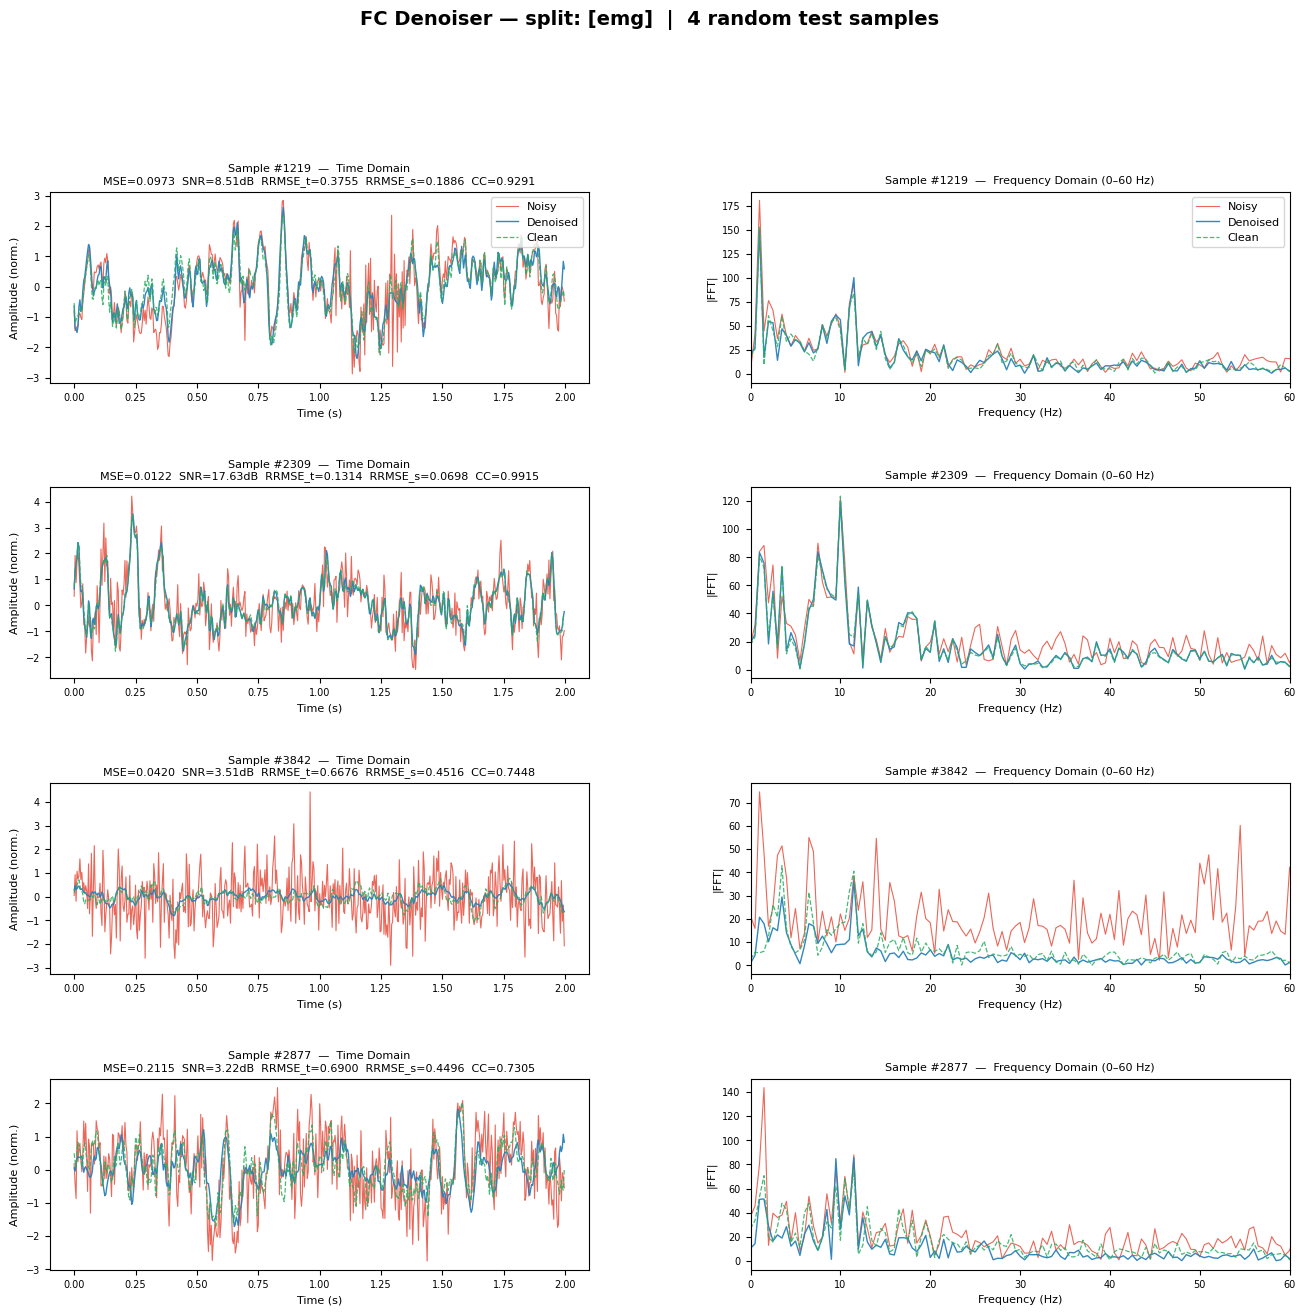


[emg]  test checkpoint metrics (saved during training):
  MSE                 : 0.076925
  SpectralLoss        : 2.114071
  SNR_dB              : 5.551021
  RRMSE_temporal      : 0.587026
  RRMSE_spectral      : 0.394413
  CC                  : 0.778220
  Plot saved → /kaggle/working/plots/fc_test_emg.png


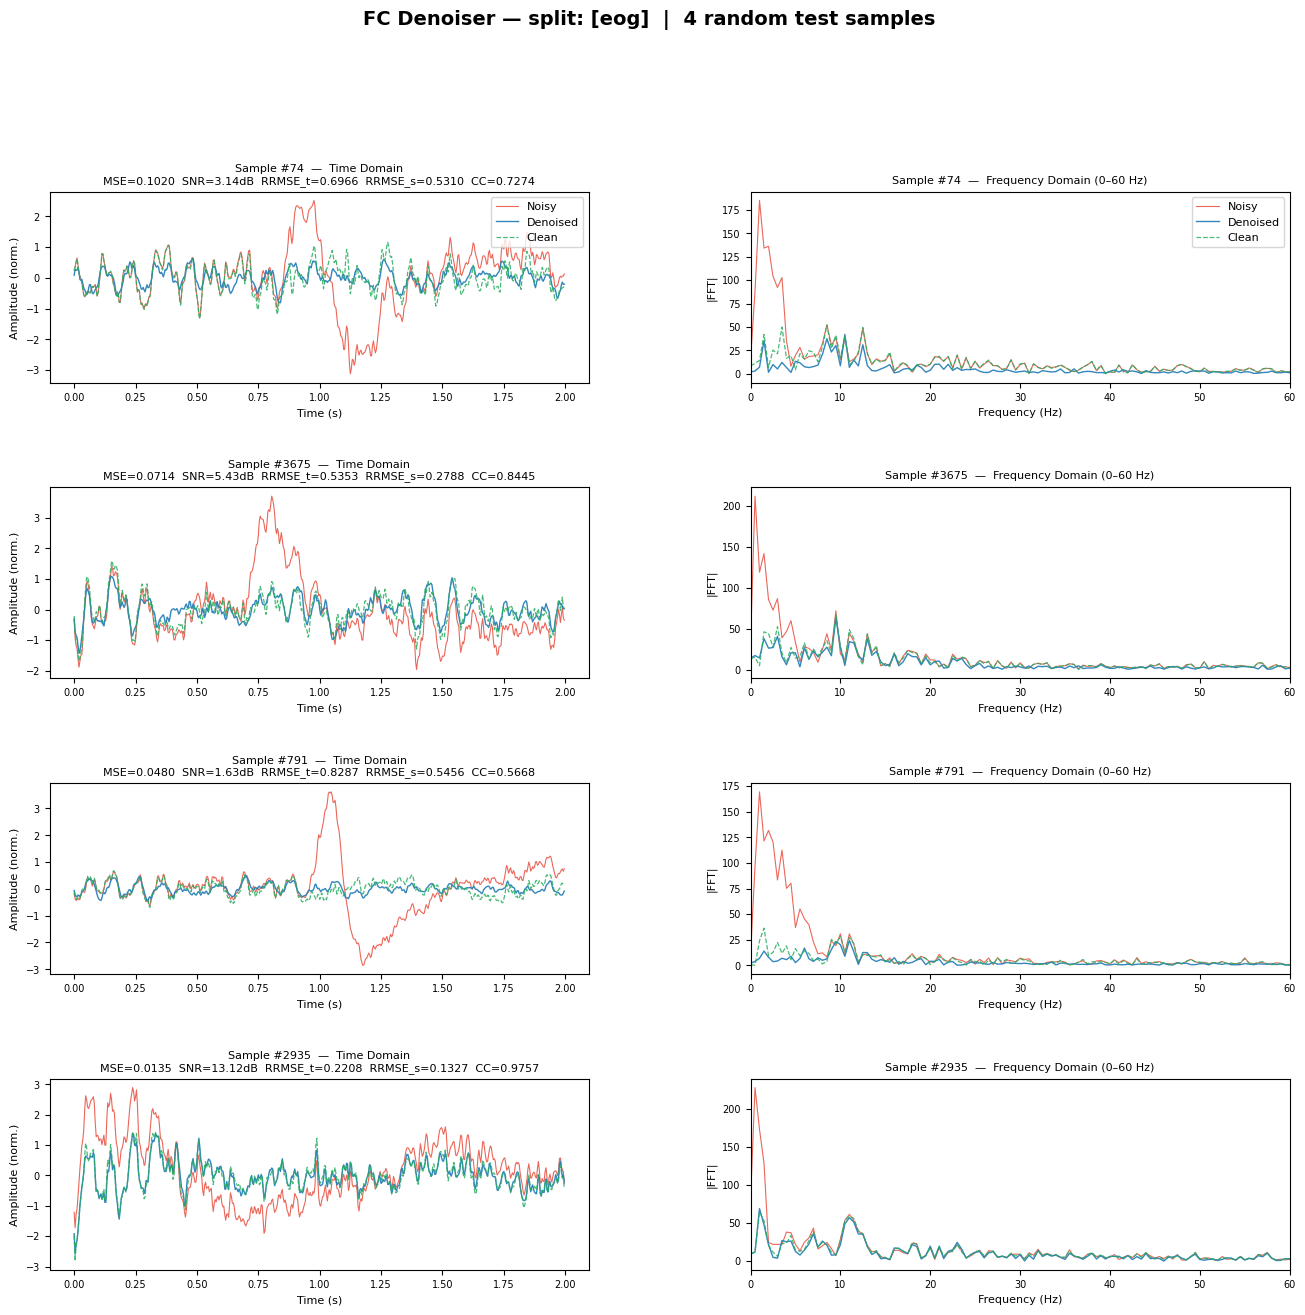


[eog]  test checkpoint metrics (saved during training):
  MSE                 : 0.048658
  SpectralLoss        : 1.540556
  SNR_dB              : 9.106676
  RRMSE_temporal      : 0.389131
  RRMSE_spectral      : 0.259721
  CC                  : 0.902887
  Plot saved → /kaggle/working/plots/fc_test_eog.png


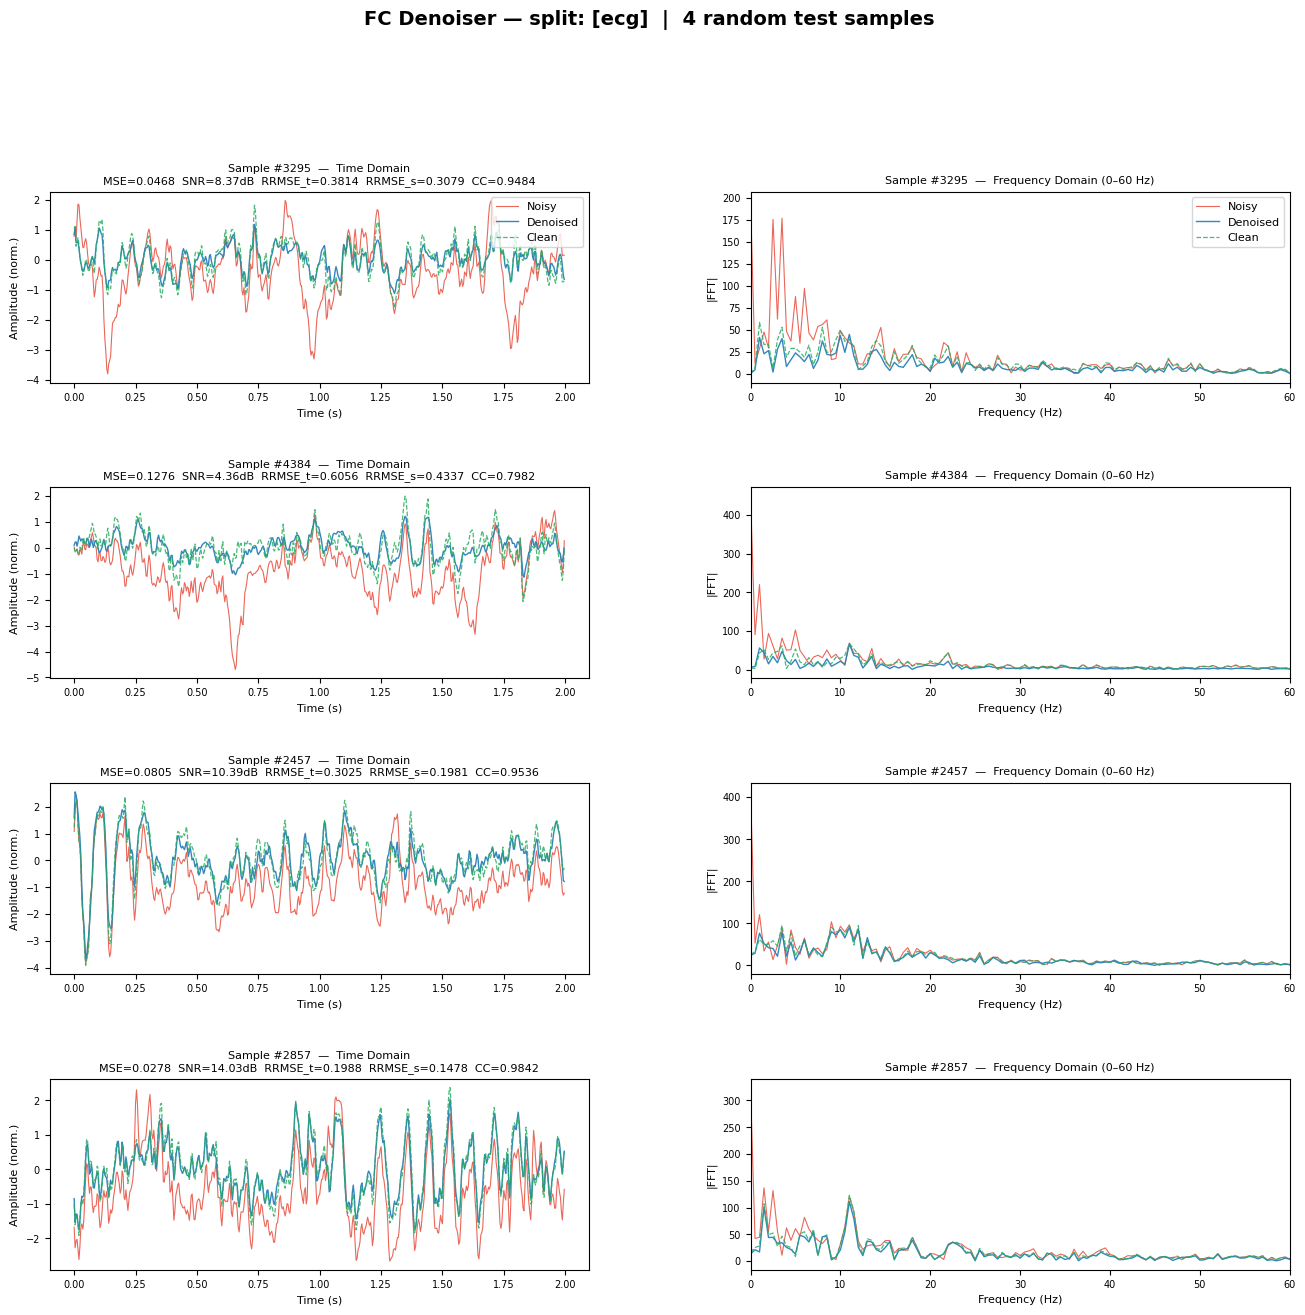


[ecg]  test checkpoint metrics (saved during training):
  MSE                 : 0.115063
  SpectralLoss        : 2.700921
  SNR_dB              : 6.042349
  RRMSE_temporal      : 0.560069
  RRMSE_spectral      : 0.396477
  CC                  : 0.793669
  Plot saved → /kaggle/working/plots/fc_test_ecg.png


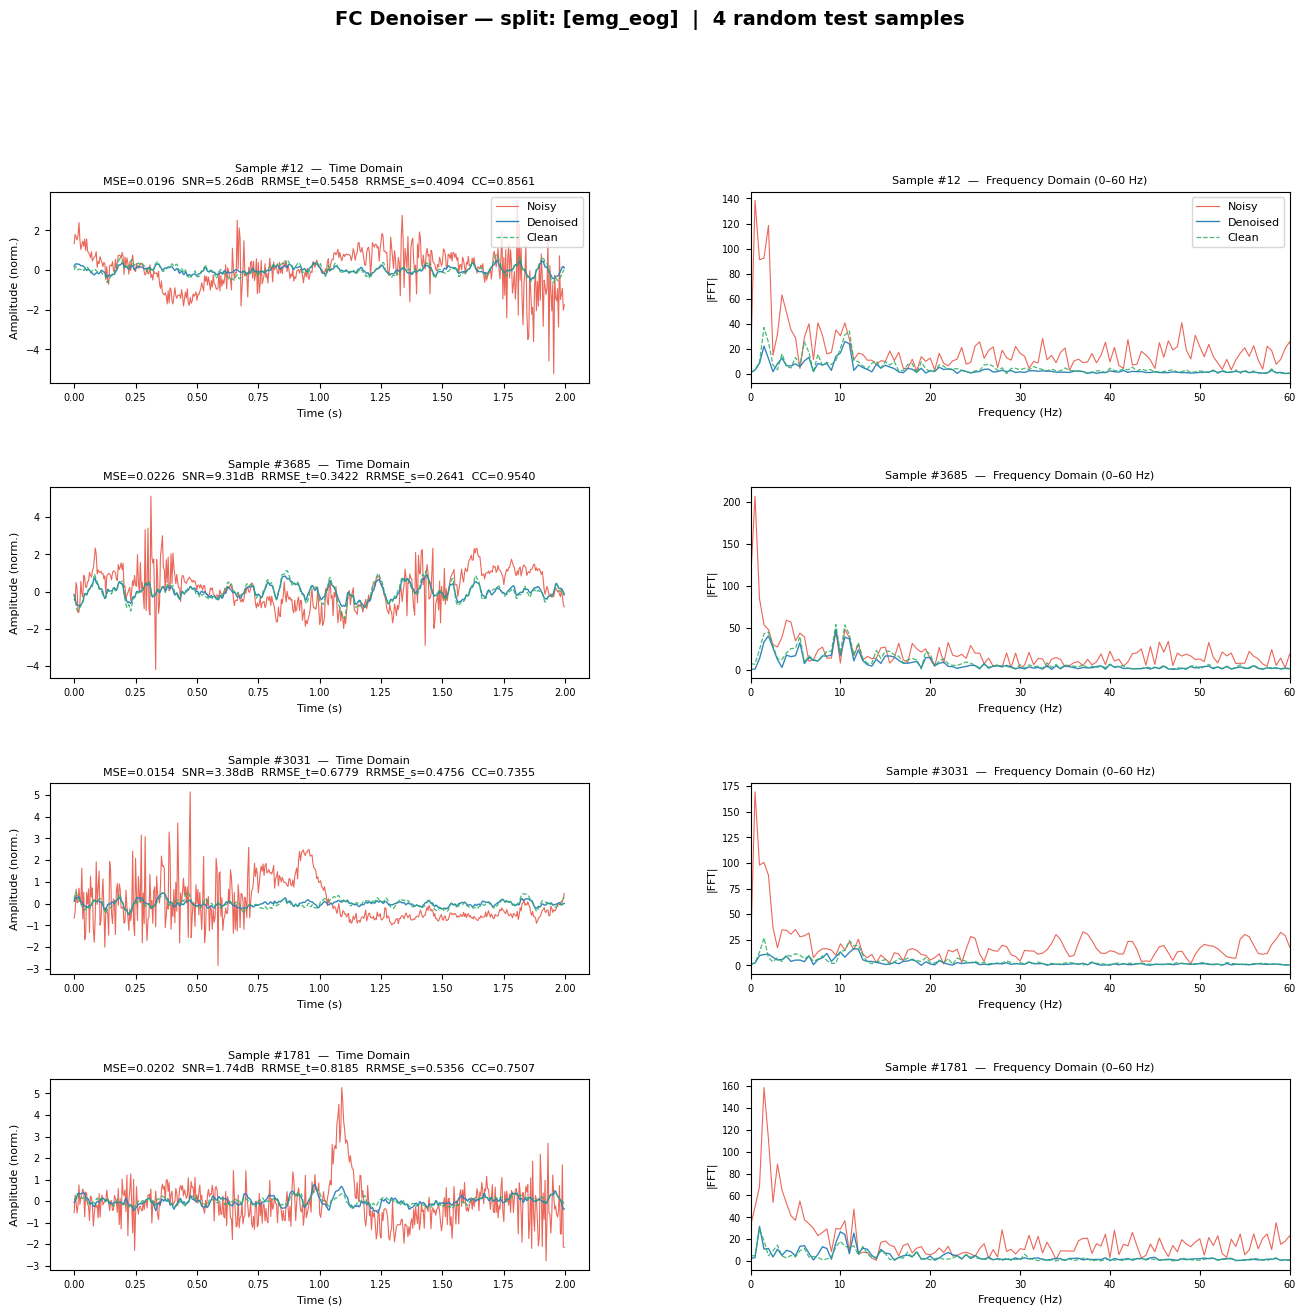


[emg_eog]  test checkpoint metrics (saved during training):
  MSE                 : 0.064668
  SpectralLoss        : 1.831106
  SNR_dB              : 4.380221
  RRMSE_temporal      : 0.659028
  RRMSE_spectral      : 0.436596
  CC                  : 0.719292
  Plot saved → /kaggle/working/plots/fc_test_emg_eog.png


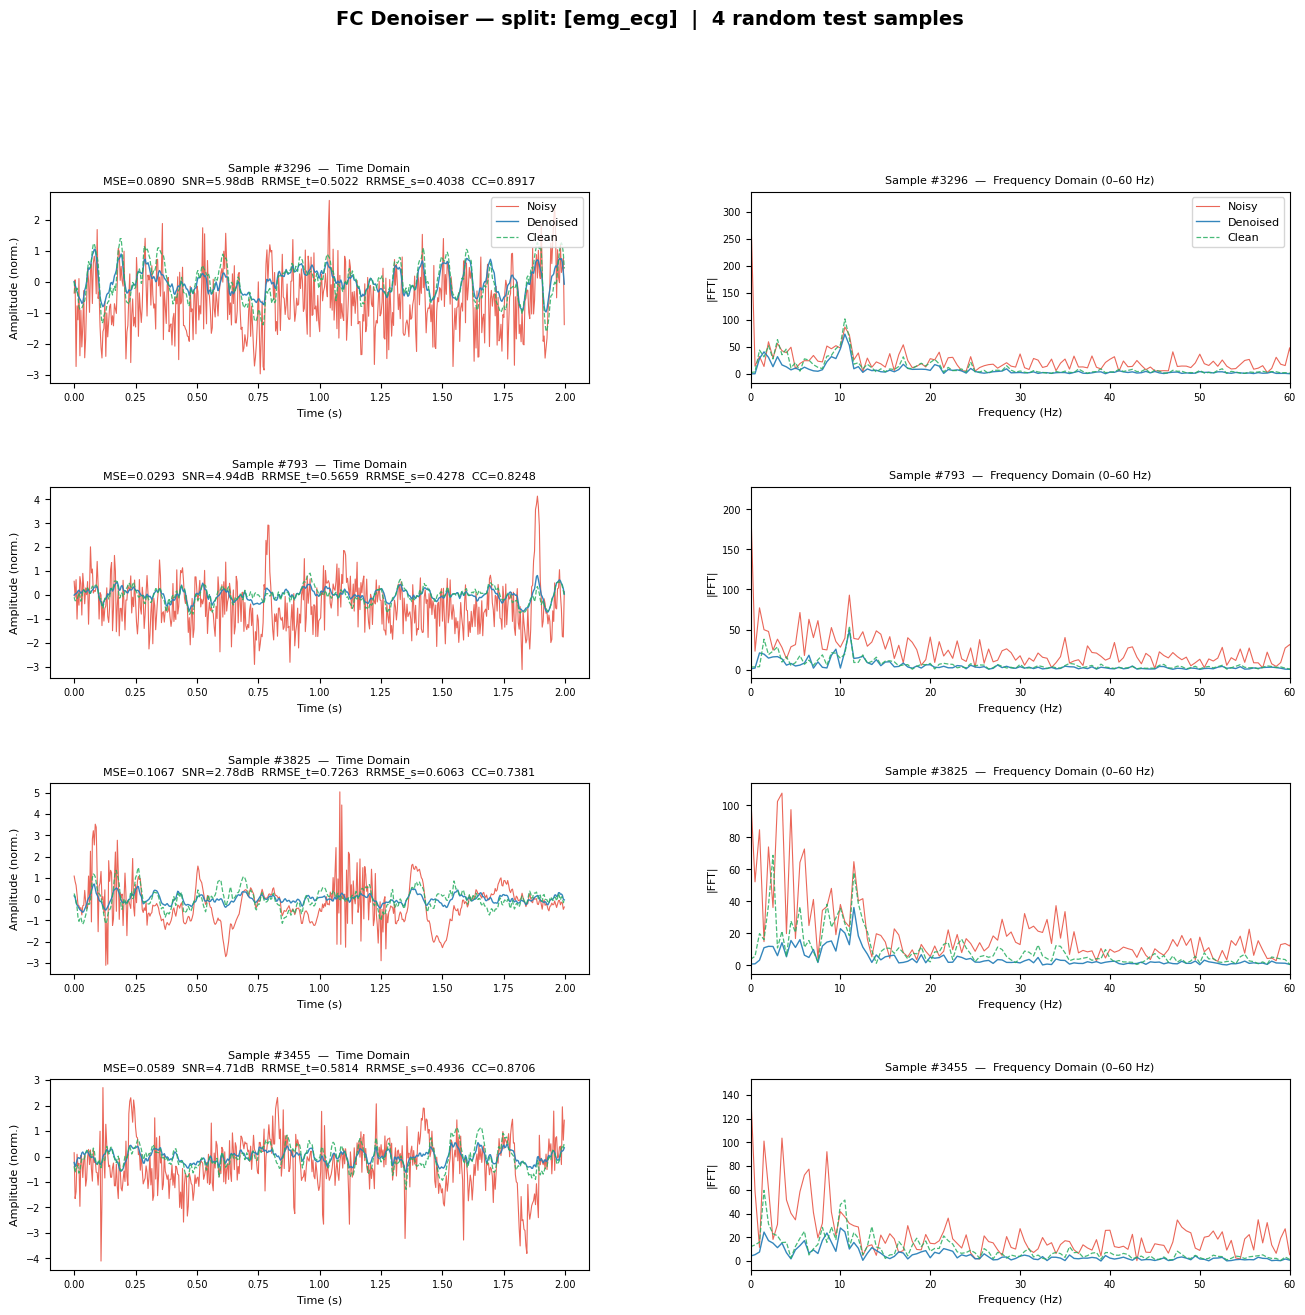


[emg_ecg]  test checkpoint metrics (saved during training):
  MSE                 : 0.092172
  SpectralLoss        : 2.405071
  SNR_dB              : 3.287848
  RRMSE_temporal      : 0.741833
  RRMSE_spectral      : 0.519483
  CC                  : 0.646978
  Plot saved → /kaggle/working/plots/fc_test_emg_ecg.png


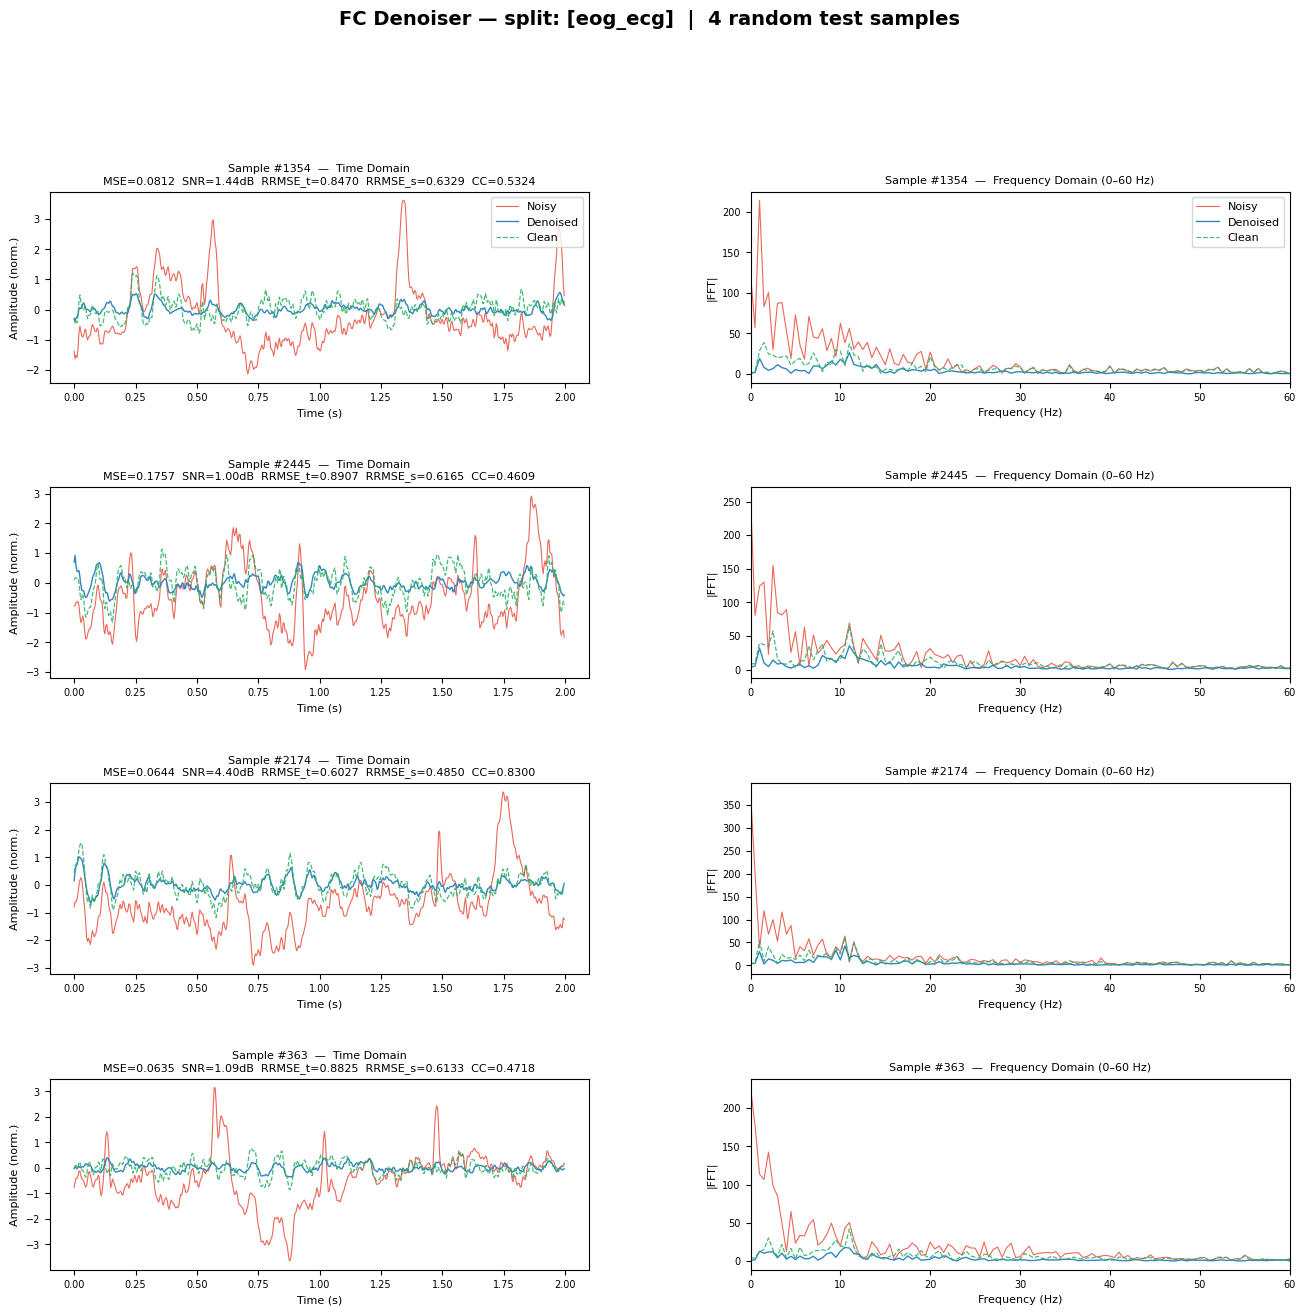


[eog_ecg]  test checkpoint metrics (saved during training):
  MSE                 : 0.075232
  SpectralLoss        : 2.067102
  SNR_dB              : 4.954564
  RRMSE_temporal      : 0.632457
  RRMSE_spectral      : 0.441184
  CC                  : 0.730663
  Plot saved → /kaggle/working/plots/fc_test_eog_ecg.png


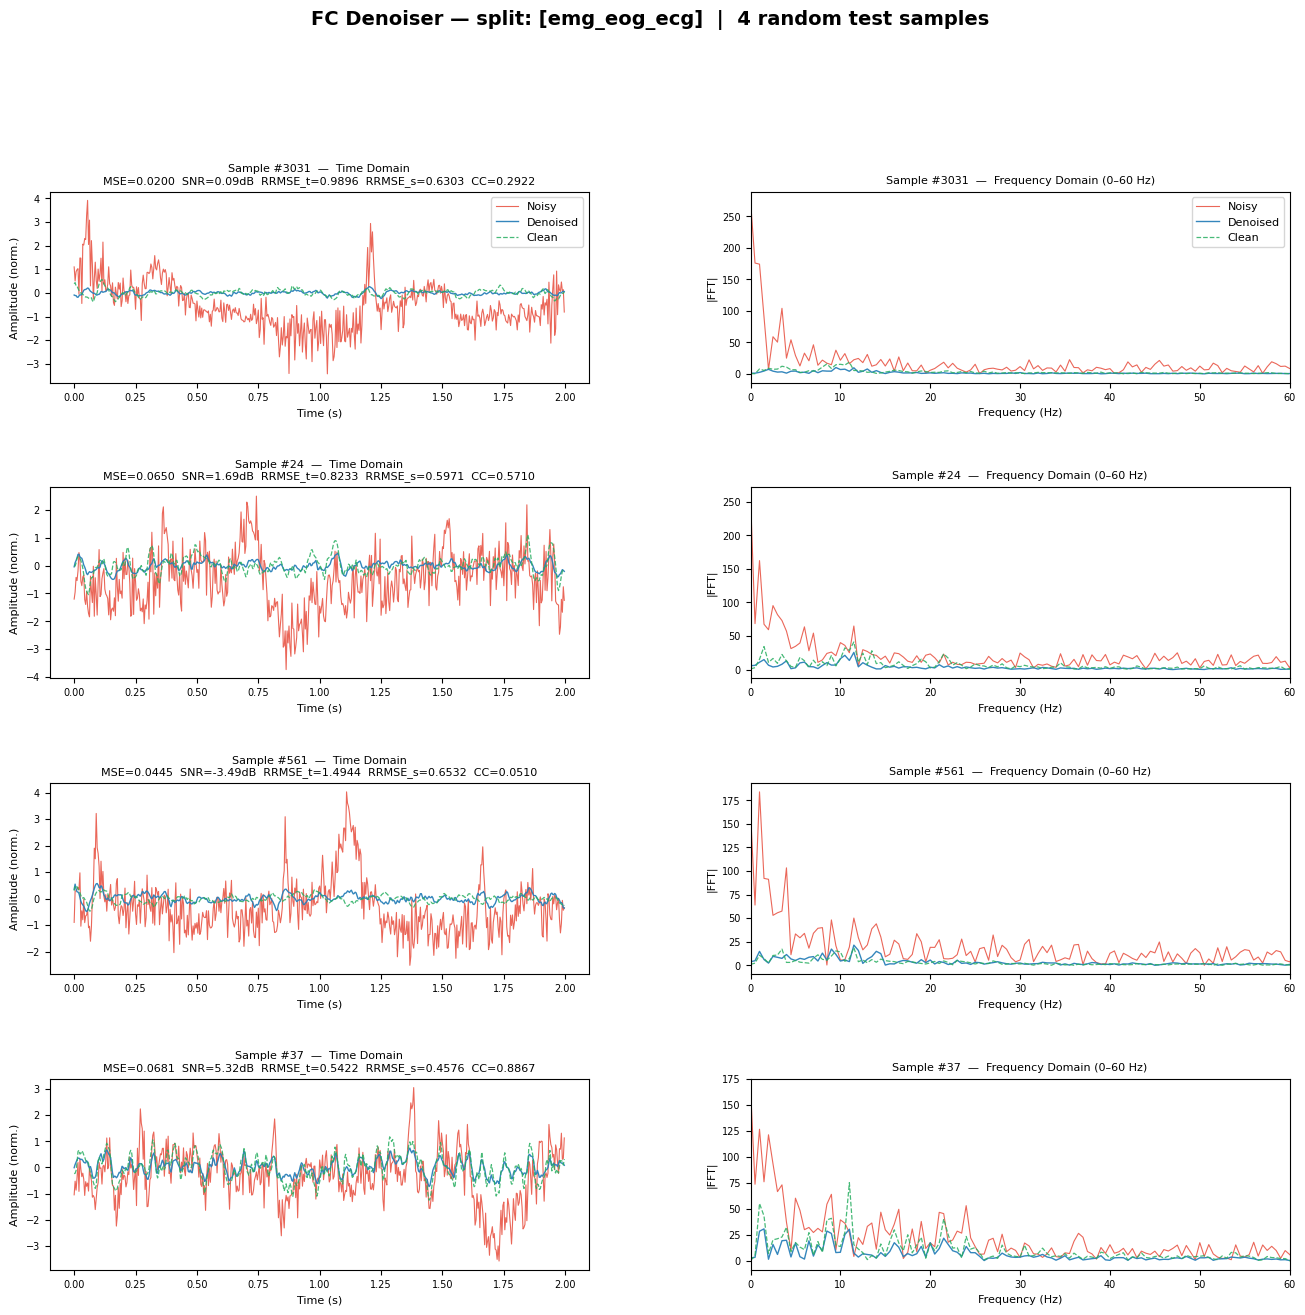


[emg_eog_ecg]  test checkpoint metrics (saved during training):
  MSE                 : 0.071318
  SpectralLoss        : 2.020872
  SNR_dB              : 2.942221
  RRMSE_temporal      : 0.769776
  RRMSE_spectral      : 0.533558
  CC                  : 0.616204
  Plot saved → /kaggle/working/plots/fc_test_emg_eog_ecg.png

Done. All splits visualised.


In [28]:
t_axis = np.arange(WIN_LEN) / FS   # 0 … 1.996 s
rng    = np.random.default_rng(SEED)
 
for combo in SPLITS:
    ckpt_path = os.path.join(CKPT_DIR, f"fc_denoiser_{combo}.pt")
    h5_path   = os.path.join(H5_DIR,   f"{combo}_test.h5")
 
    # ── guard ──
    if not os.path.exists(ckpt_path):
        print(f"[{combo}]  checkpoint not found: {ckpt_path}  — skipping")
        continue
    if not os.path.exists(h5_path):
        print(f"[{combo}]  test file not found: {h5_path}  — skipping")
        continue
 
    # ── load model ──
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    cfg   = ckpt.get("model_config", {"win_len": WIN_LEN, "dropout": 0.3})
    model = FCDenoiser(**cfg).to(DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
 
    # ── load test set ──
    with h5py.File(h5_path, "r") as hf:
        noisy_all = hf["noisy"][:]   # (N, 512) float32
        clean_all = hf["clean"][:]
 
    n_test  = len(noisy_all)
    indices = rng.choice(n_test, size=N_SAMPLES, replace=False)
 
    noisy_batch = torch.tensor(noisy_all[indices], dtype=torch.float32).to(DEVICE)
 
    with torch.no_grad():
        denoised_batch = model(noisy_batch).cpu().numpy()
 
    noisy_sel = noisy_all[indices]
    clean_sel = clean_all[indices]
 
    # ── figure: N_SAMPLES rows × 2 cols (time | spectrum) ──
    fig = plt.figure(figsize=(16, 3.5 * N_SAMPLES))
    fig.suptitle(
        f"FC Denoiser — split: [{combo}]  |  {N_SAMPLES} random test samples",
        fontsize=14, fontweight="bold", y=1.01
    )
    gs = gridspec.GridSpec(N_SAMPLES, 2, figure=fig, hspace=0.55, wspace=0.3)
 
    for row, (idx, noisy, denoised, clean) in enumerate(
        zip(indices, noisy_sel, denoised_batch, clean_sel)
    ):
        m = sample_metrics(denoised, clean)
        metric_str = (
            f"MSE={m['MSE']:.4f}  SNR={m['SNR']:.2f}dB  "
            f"RRMSE_t={m['RRMSE_t']:.4f}  RRMSE_s={m['RRMSE_s']:.4f}  CC={m['CC']:.4f}"
        )
 
        # ── left: time domain ──
        ax_t = fig.add_subplot(gs[row, 0])
        ax_t.plot(t_axis, noisy,    color="#e74c3c", lw=0.8, alpha=0.85, label="Noisy")
        ax_t.plot(t_axis, denoised, color="#2980b9", lw=1.0, alpha=0.95, label="Denoised")
        ax_t.plot(t_axis, clean,    color="#27ae60", lw=0.9, alpha=0.85,
                  linestyle="--", label="Clean")
        ax_t.set_title(f"Sample #{idx}  —  Time Domain\n{metric_str}", fontsize=8)
        ax_t.set_xlabel("Time (s)", fontsize=8)
        ax_t.set_ylabel("Amplitude (norm.)", fontsize=8)
        ax_t.tick_params(labelsize=7)
        if row == 0:
            ax_t.legend(fontsize=8, loc="upper right")
 
        # ── right: frequency domain (magnitude spectrum) ──
        freqs     = np.fft.rfftfreq(WIN_LEN, d=1.0 / FS)
        ax_f = fig.add_subplot(gs[row, 1])
        ax_f.plot(freqs, np.abs(np.fft.rfft(noisy)),    color="#e74c3c",
                  lw=0.8, alpha=0.85, label="Noisy")
        ax_f.plot(freqs, np.abs(np.fft.rfft(denoised)), color="#2980b9",
                  lw=1.0, alpha=0.95, label="Denoised")
        ax_f.plot(freqs, np.abs(np.fft.rfft(clean)),    color="#27ae60",
                  lw=0.9, alpha=0.85, linestyle="--", label="Clean")
        ax_f.set_xlim(0, 60)     # EEG-relevant band: 0–60 Hz
        ax_f.set_title(f"Sample #{idx}  —  Frequency Domain (0–60 Hz)", fontsize=8)
        ax_f.set_xlabel("Frequency (Hz)", fontsize=8)
        ax_f.set_ylabel("|FFT|", fontsize=8)
        ax_f.tick_params(labelsize=7)
        if row == 0:
            ax_f.legend(fontsize=8, loc="upper right")
 
    plt.tight_layout()
    save_path = os.path.join(PLOT_DIR, f"fc_test_{combo}.png")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
 
    # ── print summary for this split ──
    print(f"\n[{combo}]  test checkpoint metrics (saved during training):")
    for k, v in ckpt.get("test_metrics", {}).items():
        if k != "loss":
            print(f"  {k:20s}: {v:.6f}")
    print(f"  Plot saved → {save_path}")
 
print("\nDone. All splits visualised.")

In [30]:
import shutil

shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')

'/kaggle/working/plots.zip'